# How to create a simple Sequential NN using pytorch

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

## 🧱 Step 1. Create a simple dataset

- Let’s start with a toy regression example:
- Predict y = 3x + 2 with some noise.

In [3]:
# Generate data
x = torch.linspace(-5, 5, 100).unsqueeze(1)   # shape [100, 1]
y = 3 * x + 2 + torch.randn(x.size()) * 0.5   # noisy linear relation

## 🧠 Step 2. Define a neural network

- Let’s build a 2-layer fully connected NN.
### 💡 Explanation:
- nn.Linear(in, out) creates a layer that does y = xW + b
- nn.ReLU() introduces non-linearity
- forward() defines how data flows through the network

In [4]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16),   # input → hidden
            nn.ReLU(),          # activation
            nn.Linear(16, 1)    # hidden → output
        )
        
    def forward(self, x):
        return self.net(x)

## ⚙️ Step 3. Instantiate the model, loss, and optimizer
- criterion defines how we measure error.
- optimizer updates model weights using gradients (here SGD).

In [5]:
model = SimpleNN()
criterion = nn.MSELoss()          # Mean Squared Error for regression
optimizer = optim.SGD(model.parameters(), lr=0.01)

## 🔁 Step 4. Training loop
- 💡 What happens each step:
1.	preds = model(x) → forward pass
2.	loss.backward() → PyTorch computes gradients for all parameters
3.	optimizer.step() → parameters updated based on gradients


In [6]:
for epoch in range(500):
    optimizer.zero_grad()          # reset gradients
    preds = model(x)               # forward pass
    loss = criterion(preds, y)     # compute loss
    loss.backward()                # compute gradients
    optimizer.step()               # update weights

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 72.1772
Epoch 50, Loss: 0.3201
Epoch 100, Loss: 0.2535
Epoch 150, Loss: 0.2380
Epoch 200, Loss: 0.2284
Epoch 250, Loss: 0.2222
Epoch 300, Loss: 0.2180
Epoch 350, Loss: 0.2154
Epoch 400, Loss: 0.2134
Epoch 450, Loss: 0.2118


## 📈 Step 5. Test and visualize

In [9]:
with torch.no_grad():  # no gradients needed
    test_x = torch.linspace(-5, 5, 100).unsqueeze(1)
    preds = model(test_x)

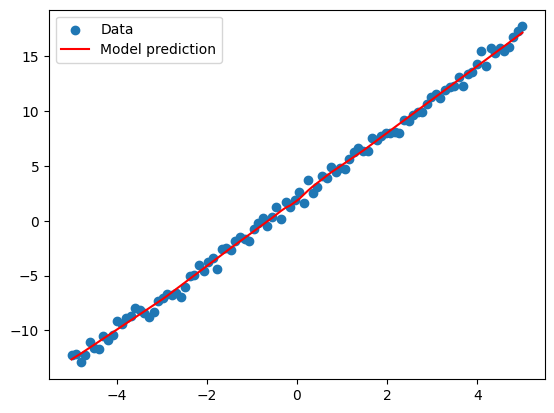

In [8]:
import matplotlib.pyplot as plt

plt.scatter(x, y, label='Data')
plt.plot(test_x, preds, color='red', label='Model prediction')
plt.legend()
plt.show()